# RNA Substrates of Stentor Learning after 4 or 19 hours 

In [1]:
#Notebook Setup

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS
from statsmodels.stats.multitest import fdrcorrection
from matplotlib import rc

import os
import pickle as pkl

rc('text', usetex=False)
rc('text.latex', preamble=r'\usepackage{cmbright}')
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

%matplotlib inline

# This enables SVG graphics inline. 
%config InlineBackend.figure_formats = {'png', 'retina'}

rc = {'lines.linewidth': 2,
      'axes.labelsize': 18, 
      'axes.titlesize': 18, 
      'axes.facecolor': 'DFDFE5'}
sns.set_context('notebook', rc=rc)
sns.set_style("dark")

mpl.rcParams['xtick.labelsize'] = 16 
mpl.rcParams['ytick.labelsize'] = 16 
mpl.rcParams['legend.fontsize'] = 14

## Load data

In [2]:
# read sleuth matrix 
df = pd.read_csv('/Volumes/albright_postdoc/deepa/exp1_sleuth_19_wald.csv').set_index('target_id')

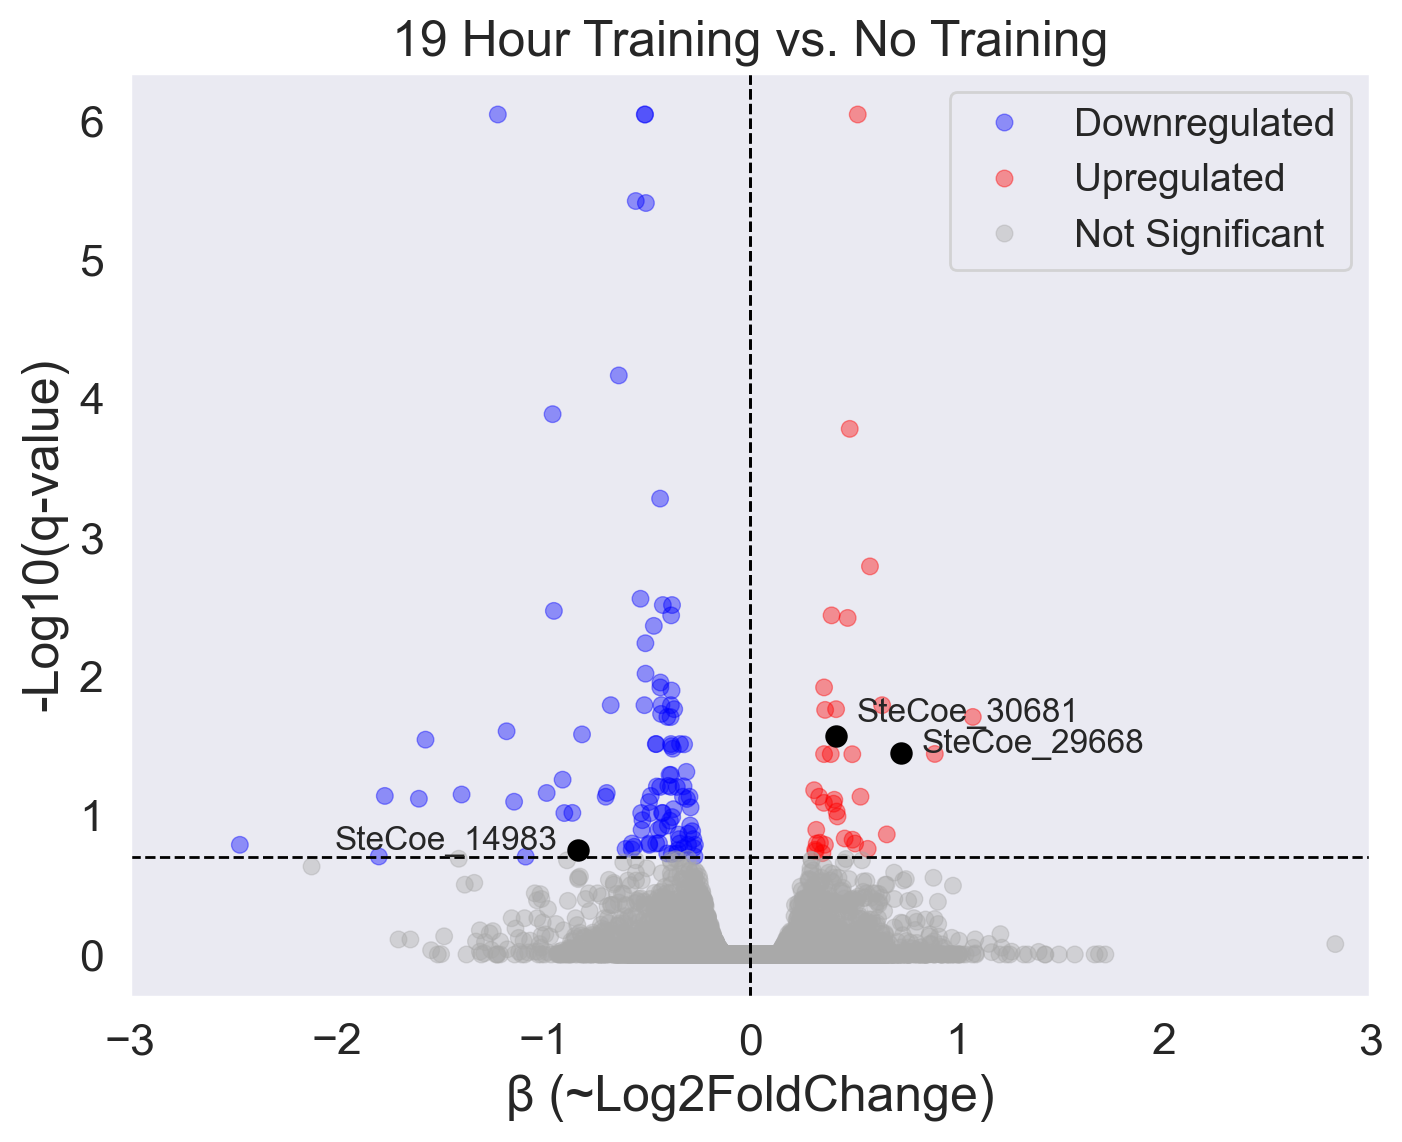

In [3]:
# define significance thresholds
padj_threshold = 0.2 # q-value threshold
logfc_threshold = 0  # Log2 fold change threshold

# significance labels based on q-value
df["significant"] = "Not Significant"
df.loc[(df["b"] > logfc_threshold) & (df["qval"] < padj_threshold), "significant"] = "Upregulated"
df.loc[(df["b"] < -logfc_threshold) & (df["qval"] < padj_threshold), "significant"] = "Downregulated"

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["b"],
    y=-np.log10(df["qval"]),
    hue=df["significant"],
    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "darkgray"},
    alpha=0.4, 
    edgecolors=None
)

# hardcoding text position because overlap

# SteCoe_29668
x_29668 = df["b"]["SteCoe_29668"]
y_29668 = -np.log10(df["qval"]["SteCoe_29668"])
plt.scatter(x_29668, y_29668, color='black', s=50)
plt.text(x_29668 + 0.1, y_29668, "SteCoe_29668", ha='left')  

# SteCoe_14983
x_14983 = df["b"]["SteCoe_14983"]
y_14983 = -np.log10(df["qval"]["SteCoe_14983"])
plt.scatter(x_14983, y_14983, color='black', s=50)
plt.text(x_14983 - 0.1, y_14983, "SteCoe_14983", ha='right')  

# SteCoe_30681
x_30681 = df["b"]["SteCoe_30681"]
y_30681 = -np.log10(df["qval"]["SteCoe_30681"])
plt.scatter(x_30681, y_30681, color='black', s=50)
plt.text(x_30681 + 0.1, y_30681 + 0.1, "SteCoe_30681", ha='left')  

# Add threshold lines
plt.axhline(-np.log10(padj_threshold), linestyle="dashed", color="black", linewidth=1)  # q-value threshold
plt.axvline(-logfc_threshold, linestyle="dashed", color="black", linewidth=1)  # logFC threshold
plt.axvline(logfc_threshold, linestyle="dashed", color="black", linewidth=1)

# set x-axis range 
plt.xlim(-3,3)

# Labels & title
plt.xlabel("β (~Log2FoldChange)")
plt.ylabel("-Log10(q-value)")
plt.legend(title="")
plt.title("19 Hour Training vs. No Training") 

plt.savefig('fig/exp1_volcano_19.png', dpi=300, bbox_inches='tight')  # Save with high resolution

plt.show()

## 4 hours

In [5]:
# read sleuth matrix 
df_4 = pd.read_csv('/Volumes/albright_postdoc/deepa/exp1_sleuth_4_wald.csv').set_index('target_id')

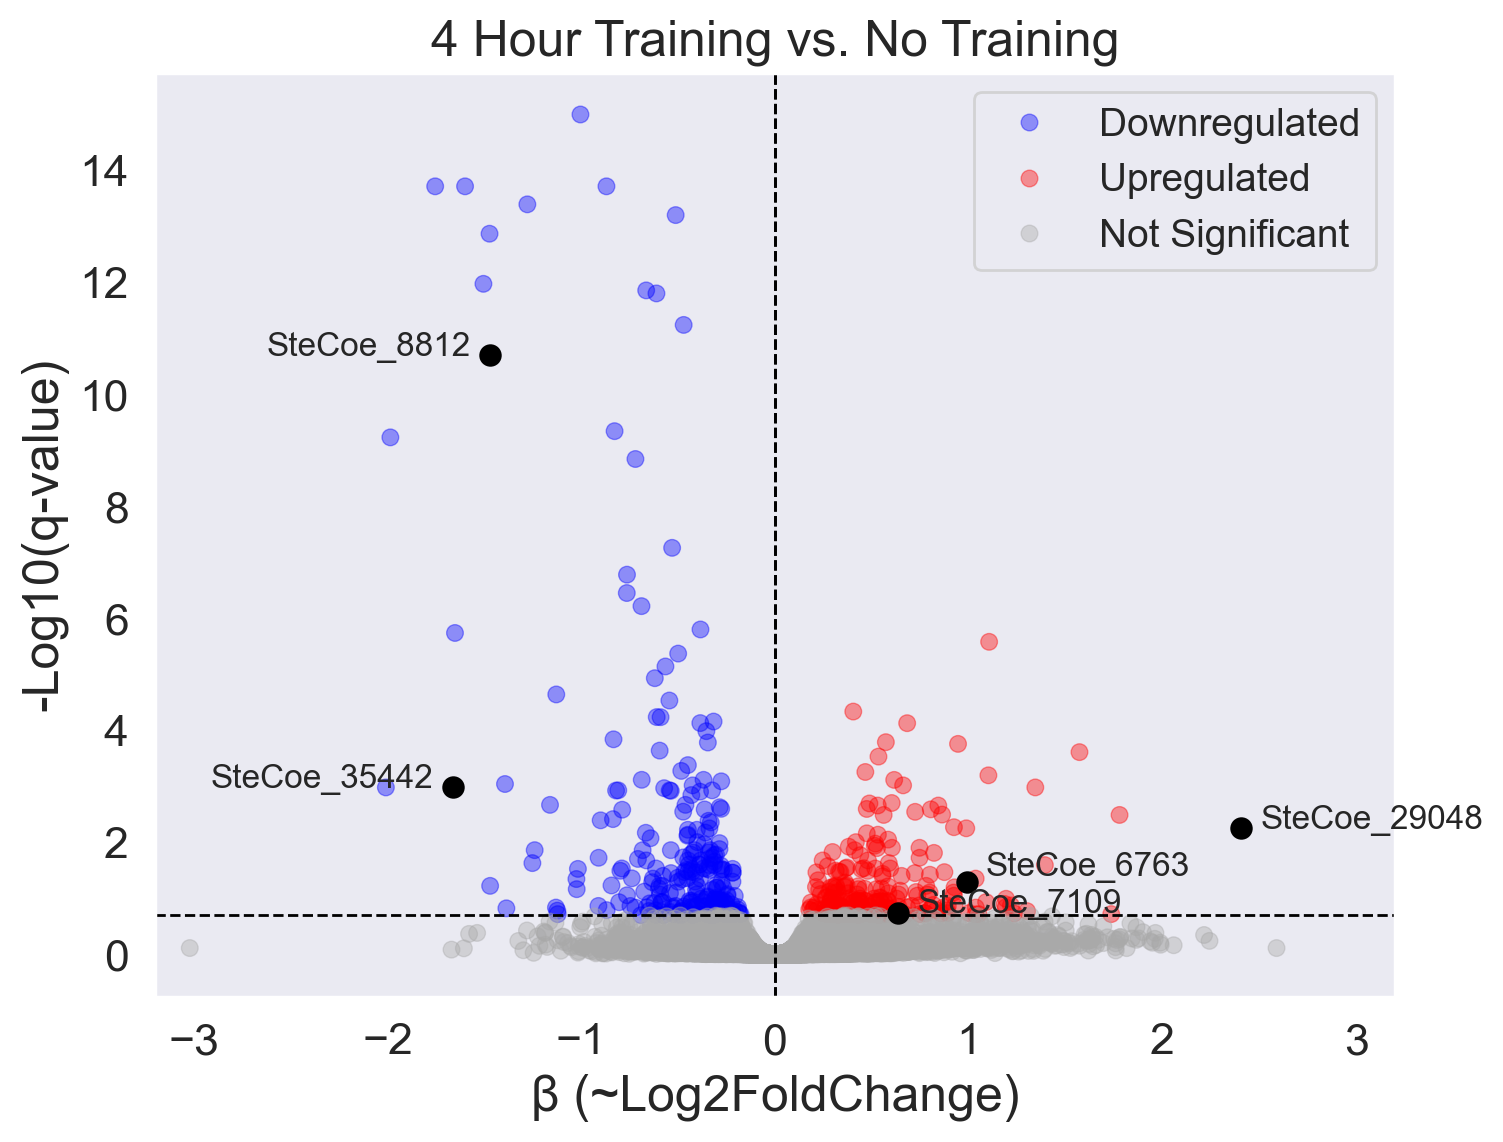

In [6]:
# define significance thresholds
padj_threshold = 0.2 # q-value threshold
logfc_threshold = 0  # Log2 fold change threshold

# significance labels based on q-value
df_4["significant"] = "Not Significant"
df_4.loc[(df_4["b"] > logfc_threshold) & (df_4["qval"] < padj_threshold), "significant"] = "Upregulated"
df_4.loc[(df_4["b"] < -logfc_threshold) & (df_4["qval"] < padj_threshold), "significant"] = "Downregulated"

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_4["b"],
    y=-np.log10(df_4["qval"]),
    hue=df_4["significant"],
    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "darkgray"},
    alpha=0.4, 
    edgecolors=None
)

# hardcoding text position because overlap

# SteCoe_35442
x_35442 = df_4["b"]["SteCoe_35442"]
y_35442 = -np.log10(df_4["qval"]["SteCoe_35442"])
plt.scatter(x_35442, y_35442, color='black', s=50)
plt.text(x_35442 - 0.1, y_35442, "SteCoe_35442", ha='right')

# SteCoe_8812
x_8812 = df_4["b"]["SteCoe_8812"]
y_8812 = -np.log10(df_4["qval"]["SteCoe_8812"])
plt.scatter(x_8812, y_8812, color='black', s=50)
plt.text(x_8812 - 0.1, y_8812, "SteCoe_8812", ha='right')  

# SteCoe_6763
x_6763 = df_4["b"]["SteCoe_6763"]
y_6763 = -np.log10(df_4["qval"]["SteCoe_6763"])
plt.scatter(x_6763, y_6763, color='black', s=50)
plt.text(x_6763 + 0.1, y_6763 + 0.1, "SteCoe_6763", ha='left')  

# SteCoe_29048
x_29048 = df_4["b"]["SteCoe_29048"]
y_29048 = -np.log10(df_4["qval"]["SteCoe_29048"])
plt.scatter(x_29048, y_29048, color='black', s=50)
plt.text(x_29048 + 0.1, y_29048, "SteCoe_29048", ha='left')  

# SteCoe_7109
x_7109 = df_4["b"]["SteCoe_7109"]
y_7109 = -np.log10(df_4["qval"]["SteCoe_7109"])
plt.scatter(x_7109, y_7109, color='black', s=50)
plt.text(x_7109 + 0.1, y_7109, "SteCoe_7109", ha='left')  

# Add threshold lines
plt.axhline(-np.log10(padj_threshold), linestyle="dashed", color="black", linewidth=1)  # qval line
plt.axvline(-logfc_threshold, linestyle="dashed", color="black", linewidth=1)  # logFC line
plt.axvline(logfc_threshold, linestyle="dashed", color="black", linewidth=1)

# set x-axis range 
plt.xlim(-3.2, 3.2)

# Labels & title
plt.xlabel("β (~Log2FoldChange)")
plt.ylabel("-Log10(q-value)")
plt.legend(title="")
plt.title("4 Hour Training vs. No Training")

plt.savefig('fig/exp1_volcano_4.png', dpi=300, bbox_inches='tight')  # Save with high resolution

plt.show()